In [57]:
# import kagglehub

# download dataset
# filepath = kagglehub.competition_download('titanic', output_dir='data')

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import xgboost as xb


## 1. Exploratory Analysis

In [59]:
df_train = pd.read_csv('data/train.csv')
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [60]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


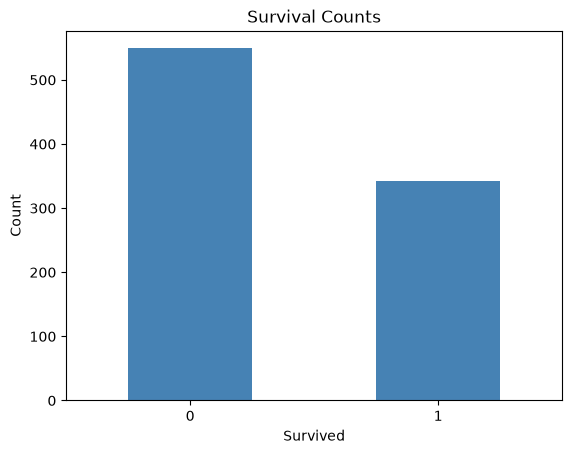

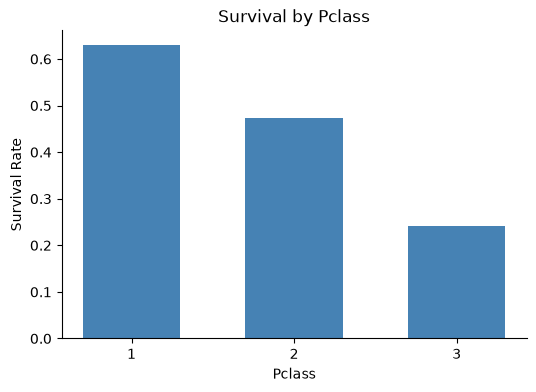

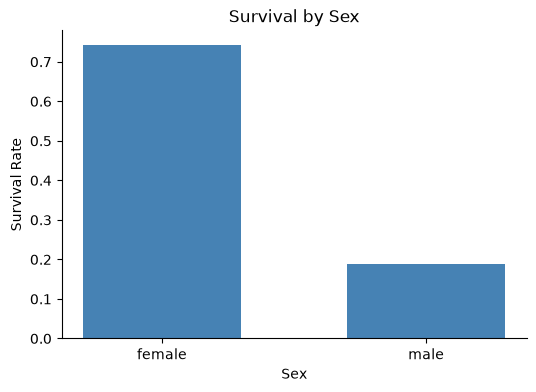

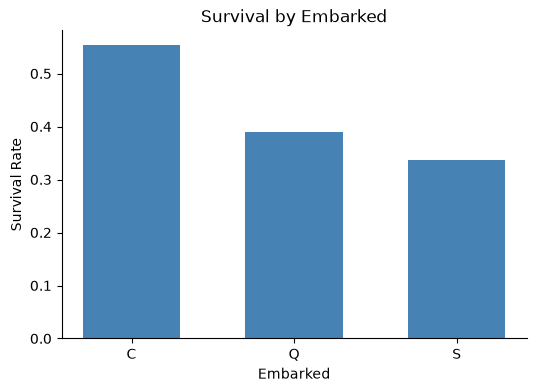

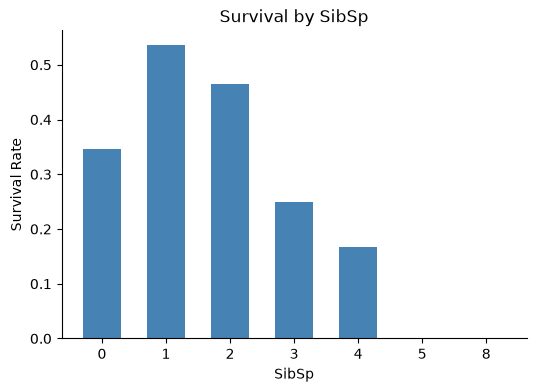

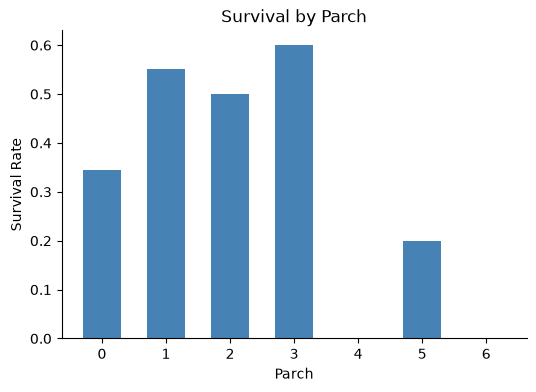

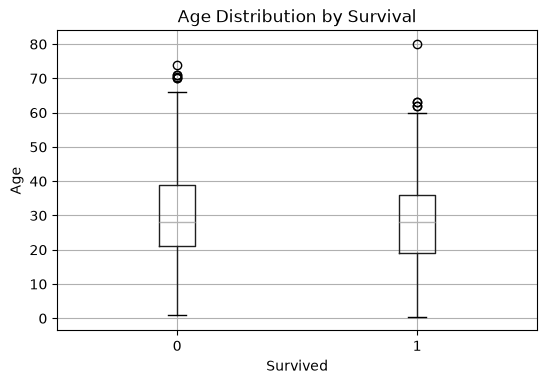

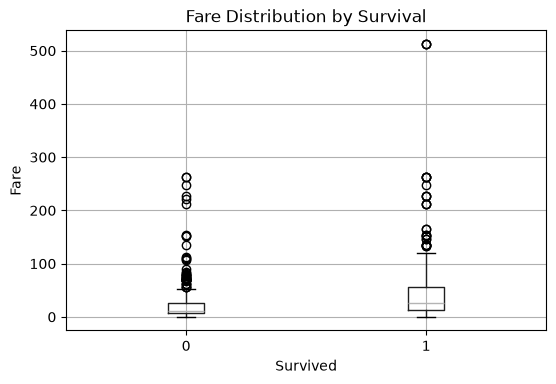

In [61]:
df_train['Survived'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Survival Counts')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

def target_by_cat(x_var: str):
    survived_by_class = df_train.groupby(x_var)['Survived'].mean()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(survived_by_class.index.astype(str), survived_by_class, color='steelblue', width=0.6)
    ax.set_xlabel(x_var)
    ax.set_ylabel('Survival Rate')
    plot_title = "Survival by " + x_var
    ax.set_title(plot_title)
    ax.spines[['top', 'right']].set_visible(False)
    plt.show()

def target_by_num(x_var: str):
    fig, ax = plt.subplots(figsize=(6,4))
    df_train.boxplot(column=x_var, by='Survived', ax=ax)
    ax.set_xlabel('Survived')
    ax.set_ylabel(x_var)
    plot_title = x_var + " Distribution by Survival"
    ax.set_title(plot_title)
    plt.suptitle('')  # removes the default pandas suptitle
    plt.show()

# target variable breakdown
target_by_cat('Pclass')
target_by_cat('Sex')
target_by_cat('Embarked')
target_by_cat('SibSp')
target_by_cat('Parch')

target_by_num('Age')
target_by_num('Fare')

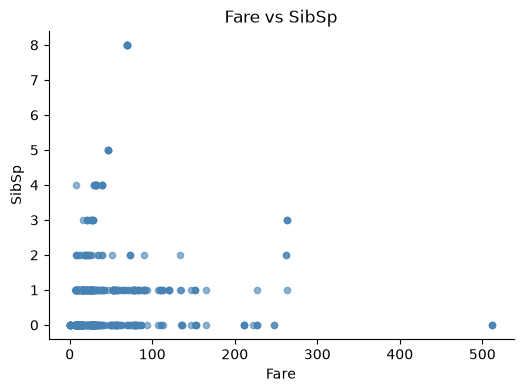

In [62]:
def scatter_x1x2(x1: str, x2:str):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df_train[x1], df_train[x2], color='steelblue', alpha=0.6, s=20)
    ax.set_xlabel(x1)
    ax.set_ylabel(x2)
    plot_title = x1 + " vs " + x2
    ax.set_title(plot_title)
    ax.spines[['top', 'right']].set_visible(False)
    plt.show()

scatter_x1x2('Fare', 'SibSp')

In [ ]:
# NOTE: scaling moved into the CV pipeline (see below) to avoid leaking
# fold statistics across train/validation splits. Numeric columns stay raw here.

In [ ]:
# new features
df_train['Title'] = df_train['Name'].str.extract(r',\s*([^\.]+)\.')
rare_titles = df_train['Title'].value_counts()[df_train['Title'].value_counts() < 10].index
df_train['Title'] = df_train['Title'].replace(rare_titles, 'Rare')
df_train['Title'] = df_train['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Cabin missingness is informative (correlates with class/fare) - keep it as its
# own explicit category rather than imputing it away
df_train['Cabin_Deck'] = df_train['Cabin'].str[0].fillna('Unknown')

df_train['SibSpByParch'] = df_train['SibSp'] * df_train['Parch']
df_train['AgeByFare'] = df_train['Age'] * df_train['Fare']
df_train['FareByFamily'] = df_train['Fare'] * df_train['SibSpByParch']


In [ ]:
# set up cross-validation and hyper-parameter tuning for XGBoost Classifier
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401 (required to unlock IterativeImputer)
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier

# Age is imputed jointly with Pclass/Fare/SibSp/Parch via MICE (regression-based,
# multivariate) rather than a single global median - much better signal since Age
# correlates strongly with class, fare, and family size.
age_impute_cols = ['Age', 'Pclass', 'Fare', 'SibSp', 'Parch']
# Derived interaction terms get simple median imputation (secondary features,
# NaN only when the underlying Age was NaN pre-imputation).
derived_numeric_cols = ['SibSpByParch', 'AgeByFare', 'FareByFamily']
categorical_cols = ['Pclass', 'Sex', 'Embarked', 'Cabin_Deck', 'Title']

feature_cols = list(dict.fromkeys(age_impute_cols + derived_numeric_cols + categorical_cols))
X = df_train[feature_cols]
y = df_train['Survived']

# each fold fits its own imputer/scaler/encoder on training data only
preprocessor = ColumnTransformer([
    ('age_group', Pipeline([
        ('impute', IterativeImputer(random_state=42)),
        ('scale', StandardScaler()),
    ]), age_impute_cols),
    ('derived_num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), derived_numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_cols),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric': 'logloss',
        'random_state': 42,
    }

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', XGBClassifier(**params)),
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print('Best params:', study.best_params)
print('Best CV accuracy:', study.best_value)

# refit the full pipeline (preprocessing + model) on all training data
best_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(**study.best_params, eval_metric='logloss', random_state=42)),
])
best_pipeline.fit(X, y)